Using device: cuda
Epoch [1/10]  Train Acc: 0.8820 | Test Acc: 0.9592
Epoch [2/10]  Train Acc: 0.9518 | Test Acc: 0.9764
Epoch [3/10]  Train Acc: 0.9621 | Test Acc: 0.9763
Epoch [4/10]  Train Acc: 0.9643 | Test Acc: 0.9809
Epoch [5/10]  Train Acc: 0.9688 | Test Acc: 0.9812
Epoch [6/10]  Train Acc: 0.9709 | Test Acc: 0.9823
Epoch [7/10]  Train Acc: 0.9730 | Test Acc: 0.9829
Epoch [8/10]  Train Acc: 0.9755 | Test Acc: 0.9844
Epoch [9/10]  Train Acc: 0.9754 | Test Acc: 0.9822
Epoch [10/10]  Train Acc: 0.9762 | Test Acc: 0.9863


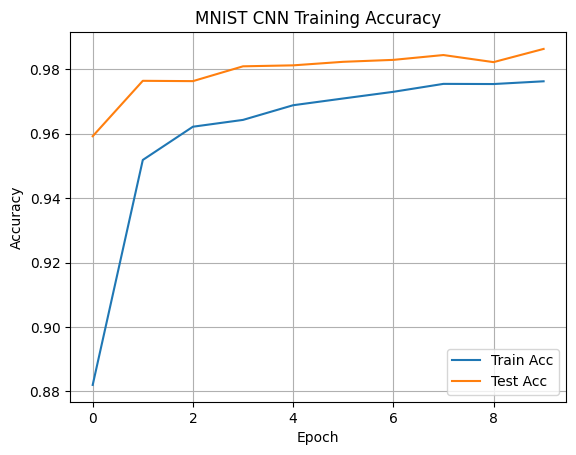

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data Augmentation & Normalization
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ==================== LOAD DATA ====================
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=60000, shuffle=True)
testloader = DataLoader(testset, batch_size=10000, shuffle=False)

X_train, y_train = next(iter(trainloader))
X_test, y_test = next(iter(testloader))

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# CNN Model
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = MNIST_CNN().to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
train_acc_list = []
test_acc_list = []

for epoch in range(1, 11):
    model.train()
    correct = 0
    total = 0
    for batch in train_loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = correct / total
    train_acc_list.append(train_acc)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch [{epoch}/10]  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# Plot Accuracy
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MNIST CNN Training Accuracy')
plt.grid(True)
plt.show()
